In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("All libraries loaded")

All libraries loaded


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

xl = pd.ExcelFile('../data/raw/Apparel_Store_Inventory_JIT_Dataset.xlsx')

sales = pd.read_excel(xl, 'Daily_Sales_Transactions', header=3)
products = pd.read_excel(xl, 'Product_Master', header=3)
inventory = pd.read_excel(xl, 'Inventory_Snapshot', header=3)
velocity = pd.read_excel(xl, 'SKU_Velocity_Summary', header=3)

print("Sales shape:", sales.shape)
print("Products shape:", products.shape)
print("Inventory shape:", inventory.shape)
print("Velocity shape:", velocity.shape)
print()
print("All data loaded successfully")

Sales shape: (45423, 11)
Products shape: (576, 19)
Inventory shape: (576, 7)
Velocity shape: (576, 18)

All data loaded successfully


In [5]:
# Fix date column and sort
sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values(['SKU', 'Date']).reset_index(drop=True)

print("Date range:", sales['Date'].min(), "to", sales['Date'].max())
print("Unique SKUs:", sales['SKU'].nunique())
print()
print("Columns:", list(sales.columns))
print()
print(sales.head())

Date range: 2026-01-01 00:00:00 to 2026-06-30 00:00:00
Unique SKUs: 576

Columns: ['Date', 'SKU', 'Store', 'Units Sold', 'MRP (INR)', 'Discount %', 'Selling Price (INR)', 'Revenue (INR)', 'Stock On Hand (Start of Day)', 'Stockout Flag', 'Day of Week']

        Date      SKU                                  Store  Units Sold  \
0 2026-01-02  AP-1001  Urban Threads - Bengaluru Mall Outlet           1   
1 2026-01-03  AP-1001  Urban Threads - Bengaluru Mall Outlet           2   
2 2026-01-08  AP-1001  Urban Threads - Bengaluru Mall Outlet           1   
3 2026-01-12  AP-1001  Urban Threads - Bengaluru Mall Outlet           1   
4 2026-01-14  AP-1001  Urban Threads - Bengaluru Mall Outlet           1   

   MRP (INR)  Discount %  Selling Price (INR)  Revenue (INR)  \
0        670           0                  670            670   
1        670           0                  670           1340   
2        670           0                  670            670   
3        670           0          

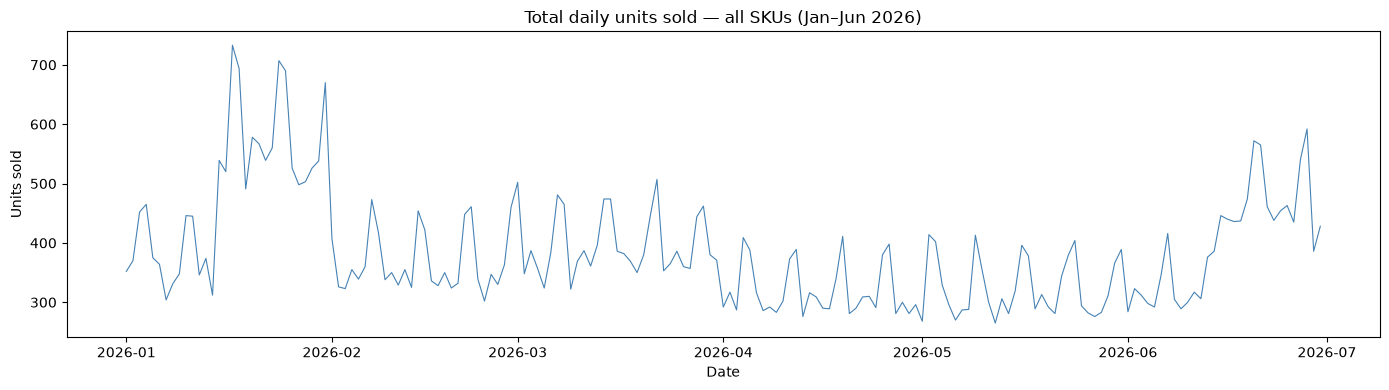

In [6]:
daily_total = sales.groupby('Date')['Units Sold'].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily_total.index, daily_total.values, linewidth=0.8, color='steelblue')
plt.title('Total daily units sold — all SKUs (Jan–Jun 2026)')
plt.xlabel('Date')
plt.ylabel('Units sold')
plt.tight_layout()
plt.show()

## EDA Finding 1 — Demand Pattern
- Clear EOSS spike in late Jan/early Feb (700+ units/day vs normal 300-500)
- Regular 7-day wave pattern confirms strong weekend effect
- Late June uptick suggests another promotional period beginning
- These patterns mean day_of_week and discount_pct must be features in our model

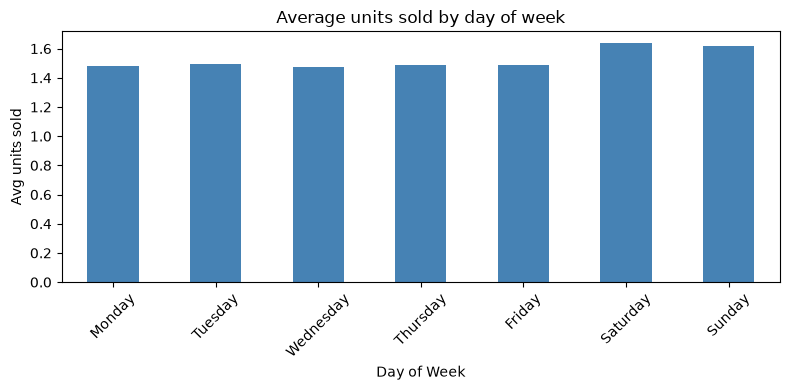

Day of Week
Monday       1.480747
Tuesday      1.494511
Wednesday    1.475980
Thursday     1.488882
Friday       1.487628
Saturday     1.636686
Sunday       1.617007
Name: Units Sold, dtype: float64


In [7]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = sales.groupby('Day of Week')['Units Sold'].mean().reindex(day_order)

day_avg.plot(kind='bar', color='steelblue', figsize=(8,4))
plt.title('Average units sold by day of week')
plt.ylabel('Avg units sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(day_avg)

## EDA Finding 2 — Weekend Effect
- Saturday and Sunday average ~1.63 units/SKU vs ~1.49 on weekdays
- Weekend uplift is real but modest (~10%)
- Day of week will be included as a feature but is not the dominant demand driver
- The bigger spikes in the time series are likely discount-driven

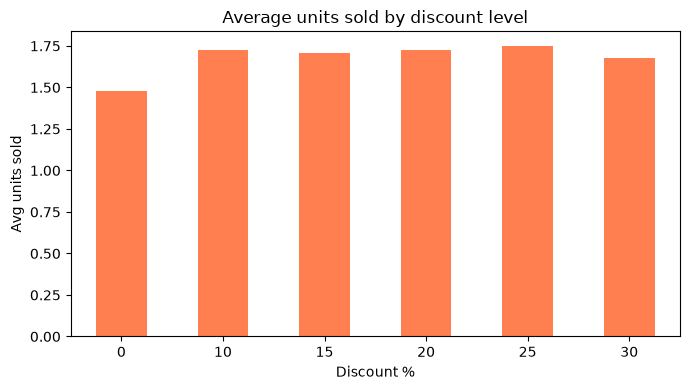

Discount %
0     1.477683
10    1.723624
15    1.707202
20    1.722828
25    1.750308
30    1.678235
Name: Units Sold, dtype: float64


In [8]:
discount_avg = sales.groupby('Discount %')['Units Sold'].mean()

discount_avg.plot(kind='bar', color='coral', figsize=(7,4))
plt.title('Average units sold by discount level')
plt.ylabel('Avg units sold')
plt.xlabel('Discount %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(discount_avg)

## EDA Finding 3 — Discount Effect
- Any discount lifts avg units sold from 1.48 to ~1.72 (~16% uplift)
- No meaningful difference between 10%, 20%, or 30% discount levels
- Discount acts as a sale period indicator, not a precise demand driver
- Will encode as binary feature: is_discount (0 or 1) rather than exact %
- The Jan/Feb spikes in time series were EOSS periods, confirmed here

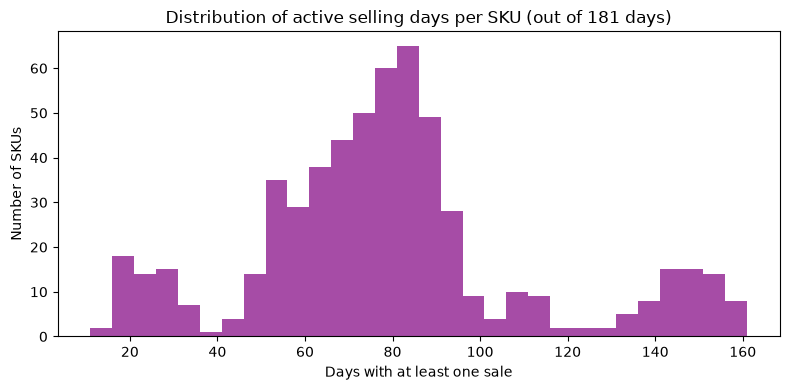

Min sale days: 11
Max sale days: 161
Median sale days: 77.0
SKUs with fewer than 30 sale days: 48
SKUs with more than 100 sale days: 94


In [9]:
sku_sale_days = sales.groupby('SKU')['Date'].nunique()

plt.figure(figsize=(8,4))
plt.hist(sku_sale_days, bins=30, color='purple', alpha=0.7)
plt.title('Distribution of active selling days per SKU (out of 181 days)')
plt.xlabel('Days with at least one sale')
plt.ylabel('Number of SKUs')
plt.tight_layout()
plt.show()

print("Min sale days:", sku_sale_days.min())
print("Max sale days:", sku_sale_days.max())
print("Median sale days:", sku_sale_days.median())
print("SKUs with fewer than 30 sale days:", (sku_sale_days < 30).sum())
print("SKUs with more than 100 sale days:", (sku_sale_days > 100).sum())

## EDA Finding 4 — SKU Sparsity
- Median SKU sells on 77 out of 181 days
- 48 SKUs have fewer than 30 sale days — too sparse for individual forecasting
- 94 SKUs have 100+ sale days — rich enough for SKU-level models
- Decision: three-tier forecasting approach based on data availability
- This directly determines which SKUs get individual vs grouped forecasts in dashboard

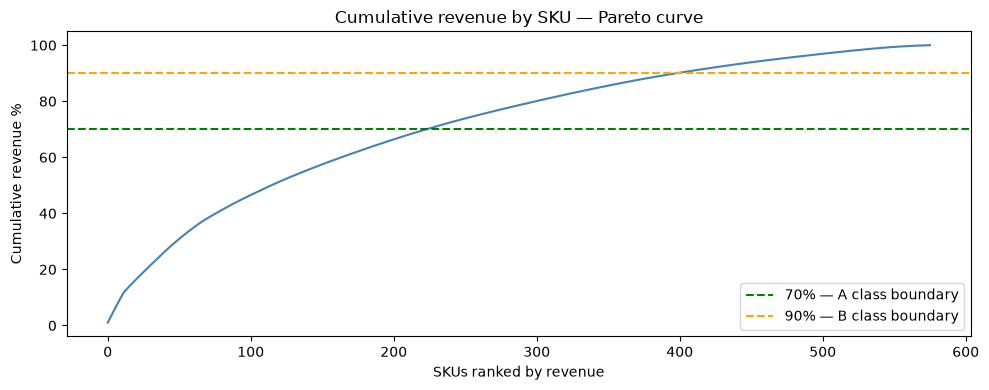

Total Revenue (INR, 6 mo)
A    223
C    178
B    175
Name: count, dtype: int64


In [10]:
# ABC Analysis
sku_revenue = velocity.groupby('SKU')['Total Revenue (INR, 6 mo)'].sum().sort_values(ascending=False)
cumulative_pct = sku_revenue.cumsum() / sku_revenue.sum() * 100

plt.figure(figsize=(10,4))
plt.plot(range(len(cumulative_pct)), cumulative_pct.values, color='steelblue')
plt.axhline(70, color='green', linestyle='--', label='70% — A class boundary')
plt.axhline(90, color='orange', linestyle='--', label='90% — B class boundary')
plt.title('Cumulative revenue by SKU — Pareto curve')
plt.xlabel('SKUs ranked by revenue')
plt.ylabel('Cumulative revenue %')
plt.legend()
plt.tight_layout()
plt.show()

# Label each SKU
def abc_label(pct):
    if pct <= 70: return 'A'
    elif pct <= 90: return 'B'
    else: return 'C'

sku_abc = cumulative_pct.apply(abc_label)
print(sku_abc.value_counts())

Total stockout events: 163
SKUs that experienced stockouts: 74



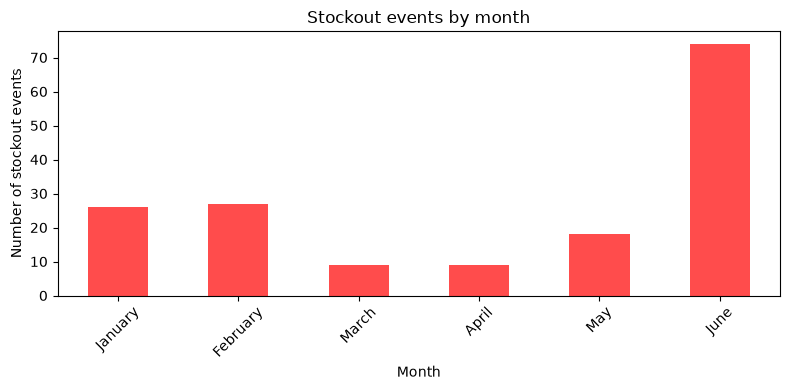

Stockouts by ABC class:
Total Revenue (INR, 6 mo)
A    46
B    19
C     9
Name: count, dtype: int64


In [11]:
stockouts = sales[sales['Stockout Flag'] == 'Yes']

print("Total stockout events:", len(stockouts))
print("SKUs that experienced stockouts:", stockouts['SKU'].nunique())
print()

stockouts['Month'] = stockouts['Date'].dt.month_name()
month_order = ['January','February','March','April','May','June']
stockout_by_month = stockouts.groupby('Month')['SKU'].count().reindex(month_order)

stockout_by_month.plot(kind='bar', color='red', alpha=0.7, figsize=(8,4))
plt.title('Stockout events by month')
plt.ylabel('Number of stockout events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Stockouts by ABC class:")
print(sku_abc[sku_abc.index.isin(stockouts['SKU'].unique())].value_counts())

## EDA Finding 6 — Stockout Analysis
- 163 stockout events across 74 SKUs in 6 months
- June accounts for 74 events (~45%) — second sale period caught store underprepared
- A-class SKUs have 46 stockouts — highest value products stocking out most
- This is the core problem: inventory system not anticipating demand spikes
- Recommendation engine must prioritise A-class SKUs and flag pre-sale period reordering

In [ ]:
wh